# Load Landcover Data from NLCD

In [2]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import Polygon
import numpy as np
import matplotlib.pyplot as plt

# Define your polygon (WGS84)
black_box = Polygon([
    (-95.1487, 26.2953), (-92.4741, 27.6542),
    (-94.7388, 32.1118), (-97.4134, 30.7530)
])
gdf_box = gpd.GeoDataFrame(geometry=[black_box], crs='EPSG:4326')

# Path to your GeoTIFF
raster_path = "Annual_NLCD_LndCov_2019_CU_C1V0.tif"

# Open and process the raster file
with rasterio.open(raster_path) as src:
    # Reproject polygon to match raster CRS
    gdf_box_proj = gdf_box.to_crs(src.crs)
    
    # Mask raster to polygon
    out_image, out_transform = mask(src, gdf_box_proj.geometry, crop=True)
    landuse_array = out_image[0]  # Get the masked data array


# Plot Urban areas & Tracked Cells in the Study Region

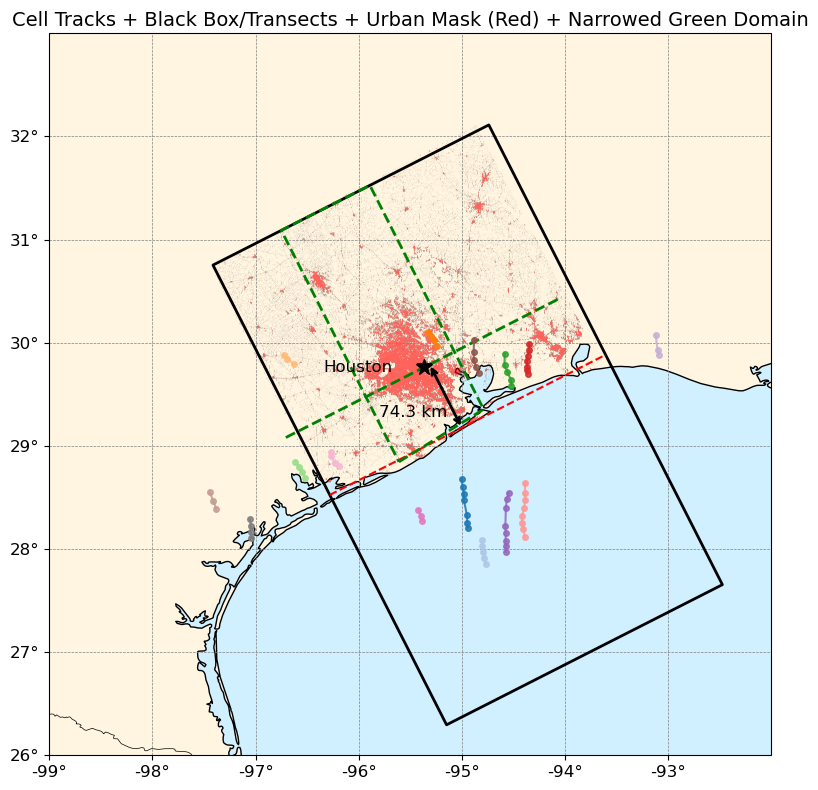

Saved: cell_tracks_blackbox_urbanmask_narrowed_greenbox_overlay.png


In [3]:
# -*- coding: utf-8 -*-
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.cm as cm
import numpy as np
from itertools import cycle
from shapely.geometry import Polygon, LineString
from shapely.affinity import rotate, translate
from geopy.distance import geodesic

from pyproj import Transformer
from rasterio.transform import xy

# ============================================================
# USER INPUTS (you already have these in script 2)
# ============================================================
# landuse_array: 2D array (NLCD classes), e.g. read from raster
# out_transform: rasterio Affine transform for landuse_array
#
# If they are already defined in your session, leave as-is.
# Otherwise load them using rasterio before running this script.
# ============================================================

# === File Paths ===
csv_file = "filtered_free_cells_202208_1km.csv"
coastline_shp = "clipped_us_coastline.shp"

# === Cell track selection ===
selected_date = "2022-08-01"
initiation_time = "03:00:00"

# === Map extent ===
plot_extent = [-99, -92, 26, 33]  # [lon_min, lon_max, lat_min, lat_max]

# === Green domain box coords (from script 2) ===
green_box_coords = [
    (-95.7, 28.8),        # P0
    (-94.7, 29.4),        # P1
    (-95.8031, 31.5711),  # P2
    (-96.8402, 31.0442)   # P3
]
delta_deg = 0.10  # narrowing amount (degrees). Try 0.05–0.20

# ============================================================
# Helper functions to narrow quadrilateral (script 2)
# ============================================================
def _unit(vec):
    v = np.asarray(vec, float)
    n = np.linalg.norm(v)
    return v / n if n != 0 else v

def _perp(vec):
    x, y = vec
    return np.array([-y, x], float)

def narrow_quadrilateral(coords, delta=0.10):
    """
    Narrow a convex quadrilateral by translating the two longer (opposite) sides
    inward toward the centroid by 'delta' lon/lat units, preserving long-side length.
    coords: 4 (lon, lat) points in polygon order.
    """
    P = np.array(coords, float)
    assert P.shape == (4, 2), "Provide exactly 4 vertices for the quadrilateral."

    edges = [(0,1), (1,2), (2,3), (3,0)]
    lens  = [np.linalg.norm(P[j] - P[i]) for (i, j) in edges]

    long_idx = np.argsort(lens)[-2:]
    long_sides = [edges[i] for i in sorted(long_idx)]

    centroid = P.mean(axis=0)
    P_new = P.copy()

    for (i, j) in long_sides:
        v = P[j] - P[i]
        n = _unit(_perp(v))
        mid_ij = 0.5 * (P[i] + P[j])
        if np.dot(centroid - mid_ij, n) < 0:
            n = -n
        shift = delta * n
        P_new[i] = P[i] + shift
        P_new[j] = P[j] + shift

    return [tuple(pt) for pt in P_new]

# ============================================================
# 1) Load cell data (script 1)
# ============================================================
df = pd.read_csv(csv_file)
df["time"] = pd.to_datetime(df["time"])

df_day = df[df["time"].dt.date == pd.to_datetime(selected_date).date()]
start_cells = df_day[df_day["time"].dt.strftime("%H:%M:%S") == initiation_time]["cell"].unique()
df_tracks = df_day[df_day["cell"].isin(start_cells)]

gdf_cells = gpd.GeoDataFrame(
    df_tracks,
    geometry=gpd.points_from_xy(df_tracks["longitude"], df_tracks["latitude"]),
    crs="EPSG:4326"
)

# ============================================================
# 2) Load coastline and compute black box + dividing line (script 1)
# ============================================================
coastline = gpd.read_file(coastline_shp)
coastline = coastline[coastline.is_valid]

def get_coastline_properties():
    coast_geom = coastline.geometry.unary_union
    coast_line = max(coast_geom.geoms, key=lambda line: line.length) if hasattr(coast_geom, "geoms") else coast_geom
    p1, p2 = list(coast_line.coords)[0], list(coast_line.coords)[-1]
    angle = np.degrees(np.arctan2(p2[1] - p1[1], p2[0] - p1[0]))
    center_lon = (p1[0] + p2[0]) / 2
    center_lat = (p1[1] + p2[1]) / 2
    return angle, center_lon, center_lat, coast_line

angle, center_lon, center_lat, coast_line = get_coastline_properties()

# Black box
box_width, box_height = 3.0, 5.0
box = Polygon([
    (center_lon - box_width/2, center_lat - box_height/2),
    (center_lon + box_width/2, center_lat - box_height/2),
    (center_lon + box_width/2, center_lat + box_height/2),
    (center_lon - box_width/2, center_lat + box_height/2)
])
black_box = rotate(box, angle, origin=(center_lon, center_lat))
black_box = translate(black_box, xoff=1.0, yoff=0.6)

# Red dividing line through black box
box_corners = list(black_box.exterior.coords)
mid1 = ((box_corners[0][0] + box_corners[3][0]) / 2, (box_corners[0][1] + box_corners[3][1]) / 2)
mid2 = ((box_corners[1][0] + box_corners[2][0]) / 2, (box_corners[1][1] + box_corners[2][1]) / 2)
dividing_line = LineString([mid1, mid2])

# Houston transect line (green dashed line in script 1)
houston_lon, houston_lat = -95.3698, 29.7604
dividing_length = np.sqrt((mid2[0] - mid1[0])**2 + (mid2[1] - mid1[1])**2)
angle_rad = np.radians(angle)
dx = dividing_length * np.cos(angle_rad)
dy = dividing_length * np.sin(angle_rad)
green_start = (houston_lon - dx/2, houston_lat - dy/2)
green_end   = (houston_lon + dx/2, houston_lat + dy/2)
houston_transect_line = LineString([green_start, green_end])

# Distance + arrow between red and green lines
mid_dividing = dividing_line.interpolate(0.5, normalized=True)
mid_green = houston_transect_line.interpolate(0.5, normalized=True)
distance_km = geodesic((mid_dividing.y, mid_dividing.x), (mid_green.y, mid_green.x)).km

unit_vec = np.array([np.cos(angle_rad), np.sin(angle_rad)])
normal_vec = np.array([-unit_vec[1], unit_vec[0]])

center_x = (mid_dividing.x + mid_green.x) / 2
center_y = (mid_dividing.y + mid_green.y) / 2

offset_deg = 0.5 * np.sqrt((mid_green.x - mid_dividing.x)**2 + (mid_green.y - mid_dividing.y)**2)
arrow_start = (center_x - normal_vec[0]*offset_deg, center_y - normal_vec[1]*offset_deg)
arrow_end   = (center_x + normal_vec[0]*offset_deg, center_y + normal_vec[1]*offset_deg)

# ============================================================
# 3) Urban mask overlay + narrowed green box (script 2)
# ============================================================
urban_codes = [21, 22, 23, 24]
urban_mask = np.isin(landuse_array, urban_codes)

nrows, ncols = landuse_array.shape
x_min, y_max = xy(out_transform, 0, 0, offset="ul")              # top-left
x_max, y_min = xy(out_transform, nrows, ncols, offset="lr")      # bottom-right

# Convert raster bounds from EPSG:5070 to lat/lon (EPSG:4326)
transformer = Transformer.from_crs("EPSG:5070", "EPSG:4326", always_xy=True)
lon_min, lat_max = transformer.transform(x_min, y_max)
lon_max, lat_min = transformer.transform(x_max, y_min)

# RGBA image: red urban mask
rgba_image = np.zeros((nrows, ncols, 4))
rgba_image[..., 0] = urban_mask.astype(float)        # Red
rgba_image[..., 3] = urban_mask.astype(float) * 0.6  # Alpha

# Narrowed green polygon
narrowed_green = narrow_quadrilateral(green_box_coords, delta=delta_deg)
green_domain_poly = Polygon(narrowed_green)

# ============================================================
# 4) Plot everything on ONE Cartopy axis
# ============================================================
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(plot_extent, crs=ccrs.PlateCarree())

# Background
ax.add_feature(cfeature.LAND, facecolor="#fff5e1")
ax.add_feature(cfeature.OCEAN, facecolor="#d0f0ff")
ax.add_feature(cfeature.COASTLINE, edgecolor="black", linewidth=1)
ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidth=0.5)

# Urban overlay (draw early so lines/points go on top)
ax.imshow(
    rgba_image,
    extent=[lon_min, lon_max, lat_min, lat_max],
    origin="upper",
    transform=ccrs.PlateCarree(),
    zorder=2
)

# Black box + lines
ax.add_geometries([black_box], crs=ccrs.PlateCarree(),
                  edgecolor="black", facecolor="none", linewidth=2, zorder=4)
ax.add_geometries([dividing_line], crs=ccrs.PlateCarree(),
                  edgecolor="red", linestyle="--", linewidth=1.5, zorder=5)
ax.add_geometries([houston_transect_line], crs=ccrs.PlateCarree(),
                  edgecolor="green", linestyle="--", linewidth=2, zorder=5)

# Narrowed green domain box
ax.add_geometries([green_domain_poly], crs=ccrs.PlateCarree(),
                  edgecolor="green", facecolor="none", linestyle="--", linewidth=2, zorder=6)

# Houston marker + label
ax.plot(houston_lon, houston_lat, marker="*", color="black",
        markersize=12, transform=ccrs.PlateCarree(), zorder=7)
ax.text(houston_lon - 0.3, houston_lat, "Houston", fontsize=12, color="black",
        ha="right", va="center", transform=ccrs.PlateCarree(), zorder=7)

# Plot cell tracks
cmap = cm.get_cmap("tab20")
colors = cycle([cmap(i % cmap.N) for i in range(len(start_cells))])

for (cell_id, cell_data), color in zip(gdf_cells.groupby("cell"), colors):
    sorted_data = cell_data.sort_values("time")
    ax.plot(sorted_data.geometry.x, sorted_data.geometry.y,
            transform=ccrs.PlateCarree(),
            linestyle="-", marker="o",
            markersize=4, linewidth=1.5, alpha=0.85,
            color=color, zorder=8)

# Double arrow + label (distance between transects)
arrowprops = dict(arrowstyle="<->", color="black", linewidth=2)
ax.annotate("", xy=arrow_start, xytext=arrow_end,
            arrowprops=arrowprops, transform=ccrs.PlateCarree(), zorder=9)

label_offset_x = -normal_vec[1] * 0.35
label_offset_y =  normal_vec[0] * 0.35
label_x = center_x + label_offset_x
label_y = center_y + label_offset_y
ax.text(label_x, label_y, f"{distance_km:.1f} km",
        fontsize=12, color="black", ha="center", va="center",
        transform=ccrs.PlateCarree(), zorder=9)

# Grid / ticks (keep your 1-degree ticks like script 1)
xticks = np.arange(-99, -92, 1)
yticks = np.arange(26, 33, 1)
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
ax.set_xticklabels([f"{lon}°" for lon in xticks], fontsize=12)
ax.set_yticklabels([f"{lat}°" for lat in yticks], fontsize=12)
ax.gridlines(draw_labels=False, linewidth=0.5, color="gray", linestyle="--")

ax.set_title(
    "Cell Tracks + Black Box/Transects + Urban Mask (Red) + Narrowed Green Domain",
    fontsize=14
)

# Save
plt.tight_layout()
outname = "cell_tracks_blackbox_urbanmask_narrowed_greenbox_overlay.png"
plt.savefig(outname, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", outname)
